In [96]:
import pandas as pd

# Excel 데이터 불러오기
df = pd.read_excel("안산 BED1 데이터(25.02.25~25.09.04).xlsx")

# 기본 정보 확인
print(df.shape)
print(df.columns)
print(df.head())
print(df.info())


# Date + Time 문자열 만들기
datetime_text = (
    df["Date"].astype(str) + " " + df["Time"].astype(str)
)

# 변환이 불가능한 날짜는 NaT로 처리
parsed_datetime = pd.to_datetime(
    datetime_text,
    errors="coerce"
)

# 날짜 변환에 실패한 행 찾기
invalid_rows = df[parsed_datetime.isna()]

print("[잘못된 날짜 데이터]")
print(invalid_rows[["Date", "Time"]])

print("\n잘못된 날짜 개수:", len(invalid_rows))

# 2월 28일 ~ 3월 2일 데이터 확인
mask = df["Date"].astype(str).isin([
    "2025-02-28",
    "2025-02-29",
    "2025-03-01",
    "2025-03-02"
])

(4608, 73)
Index(['Date', 'Time', 'Temp', 'Humi', '1-SetCurr', '1-OutVolt', '1-OutCurr',
       '1-Res', '2-SetCurr', '2-OutVolt', '2-OutCurr', '2-Res', '3-SetCurr',
       '3-OutVolt', '3-OutCurr', '3-Res', '4-SetCurr', '4-OutVolt',
       '4-OutCurr', '4-Res', '5-SetCurr', '5-OutVolt', '5-OutCurr', '5-Res',
       '6-SetCurr', '6-OutVolt', '6-OutCurr', '6-Res', '7-SetCurr',
       '7-OutVolt', '7-OutCurr', '7-Res', '8-SetCurr', '8-OutVolt',
       '8-OutCurr', '8-Res', '9-SetCurr', '9-OutVolt', '9-OutCurr', '9-Res',
       '10-SetCurr', '10-OutVolt', '10-OutCurr', '10-Res', '11-SetCurr',
       '11-OutVolt', '11-OutCurr', '11-Res', '12-SetCurr', '12-OutVolt',
       '12-OutCurr', '12-Res', '13-SetCurr', '13-OutVolt', '13-OutCurr',
       '13-Res', '14-SetCurr', '14-OutVolt', '14-OutCurr', '14-Res',
       '15-SetCurr', '15-OutVolt', '15-OutCurr', '15-Res', '16-SetCurr',
       '16-OutVolt', '16-OutCurr', '16-Res', 'TB1-Temp', 'TB1-Humi',
       'TB1-Volt', 'TB1-Min', 'TB1-Max'],
    

C:\Users\gbytk\AppData\Local\Temp\ipykernel_21548\49674911.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_datetime = pd.to_datetime(


In [97]:
# 잘못된 날짜(2025-02-29) 제거
df = df[df["Date"].astype(str) != "2025-02-29"].copy()

print("삭제 후 데이터 개수:", len(df))

삭제 후 데이터 개수: 4584


In [98]:
# Date + Time → timestamp 생성
df["timestamp"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str)
)

# 시간순 정렬
df = df.sort_values("timestamp").reset_index(drop=True)

print(df[["Date", "Time", "timestamp"]].head())

C:\Users\gbytk\AppData\Local\Temp\ipykernel_21548\4249038965.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(


                  Date      Time           timestamp
0  2025-02-25 00:00:00  14:30:01 2025-02-25 14:30:01
1  2025-02-25 00:00:00  15:30:01 2025-02-25 15:30:01
2  2025-02-25 00:00:00  16:30:01 2025-02-25 16:30:01
3  2025-02-25 00:00:00  17:30:01 2025-02-25 17:30:01
4  2025-02-25 00:00:00  18:30:01 2025-02-25 18:30:01


In [99]:
# 이전 데이터와 시간 차이 계산
df["time_diff"] = df["timestamp"].diff()

print("[시간 간격별 개수]")
print(df["time_diff"].value_counts().sort_index())

print("\n[첫 데이터]")
print(df[["timestamp", "time_diff"]].head())

print("\n[마지막 데이터]")
print(df[["timestamp", "time_diff"]].tail())

[시간 간격별 개수]
time_diff
0 days 00:59:59      13
0 days 01:00:00    4557
0 days 01:00:01      13
Name: count, dtype: int64

[첫 데이터]
            timestamp       time_diff
0 2025-02-25 14:30:01             NaT
1 2025-02-25 15:30:01 0 days 01:00:00
2 2025-02-25 16:30:01 0 days 01:00:00
3 2025-02-25 17:30:01 0 days 01:00:00
4 2025-02-25 18:30:01 0 days 01:00:00

[마지막 데이터]
               timestamp       time_diff
4579 2025-09-04 09:30:01 0 days 01:00:00
4580 2025-09-04 10:30:01 0 days 01:00:00
4581 2025-09-04 11:30:01 0 days 01:00:00
4582 2025-09-04 12:30:01 0 days 01:00:00
4583 2025-09-04 13:30:01 0 days 01:00:00


## 이부분에서 확인하려는 내용은 하나입니다.
### 이 데이터가 실제로 대부분 1시간 간격으로 연속적으로 수집됐는가?

#### 내용에서 알 수 있듯이 대부분의 시간 간격은 1시간이고 오차도 ±1초 정도로 활용하기 아주 좋은 상태입니다.


In [100]:
# 결측값 확인

missing_count = df.isnull().sum()

print("\n[컬럼별 결측값]")
print(missing_count[missing_count > 0])


[컬럼별 결측값]
time_diff    1
dtype: int64


## 우리가 만든 time_diff의 첫번째 데이터에는 
## 앞의 시간이 없음으로 결측값이 1로 나와있지만
## 실제 데이터로는 결측값이 하나도 없는 상태와 같습니다.

In [101]:
# ============================
# 채널별 컬럼 분류
# ============================

setcurr_cols = [col for col in df.columns if "SetCurr" in col]
outvolt_cols = [col for col in df.columns if "OutVolt" in col]
outcurr_cols = [col for col in df.columns if "OutCurr" in col]
res_cols = [col for col in df.columns if "-Res" in col]

print("[SetCurr 컬럼]")
print(setcurr_cols)

print("\n[OutVolt 컬럼]")
print(outvolt_cols)

print("\n[OutCurr 컬럼]")
print(outcurr_cols)

print("\n[Res 컬럼]")
print(res_cols)

[SetCurr 컬럼]
['1-SetCurr', '2-SetCurr', '3-SetCurr', '4-SetCurr', '5-SetCurr', '6-SetCurr', '7-SetCurr', '8-SetCurr', '9-SetCurr', '10-SetCurr', '11-SetCurr', '12-SetCurr', '13-SetCurr', '14-SetCurr', '15-SetCurr', '16-SetCurr']

[OutVolt 컬럼]
['1-OutVolt', '2-OutVolt', '3-OutVolt', '4-OutVolt', '5-OutVolt', '6-OutVolt', '7-OutVolt', '8-OutVolt', '9-OutVolt', '10-OutVolt', '11-OutVolt', '12-OutVolt', '13-OutVolt', '14-OutVolt', '15-OutVolt', '16-OutVolt']

[OutCurr 컬럼]
['1-OutCurr', '2-OutCurr', '3-OutCurr', '4-OutCurr', '5-OutCurr', '6-OutCurr', '7-OutCurr', '8-OutCurr', '9-OutCurr', '10-OutCurr', '11-OutCurr', '12-OutCurr', '13-OutCurr', '14-OutCurr', '15-OutCurr', '16-OutCurr']

[Res 컬럼]
['1-Res', '2-Res', '3-Res', '4-Res', '5-Res', '6-Res', '7-Res', '8-Res', '9-Res', '10-Res', '11-Res', '12-Res', '13-Res', '14-Res', '15-Res', '16-Res']


### 여기서는 앞으로 우리가 분석할 각 채널의 범위값을 알아보기전
### 예상하는 컬럼이 실제로 존재하는지 확인합니다.

In [102]:
# ============================
# 채널별 데이터 범위 확인
# ============================

channel_summary = []

for ch in range(1, 17):

    channel_summary.append({
        "Channel": ch,

        "SetCurr_min": df[f"{ch}-SetCurr"].min(),
        "SetCurr_mean": df[f"{ch}-SetCurr"].mean(),
        "SetCurr_max": df[f"{ch}-SetCurr"].max(),

        "OutVolt_min": df[f"{ch}-OutVolt"].min(),
        "OutVolt_mean": df[f"{ch}-OutVolt"].mean(),
        "OutVolt_max": df[f"{ch}-OutVolt"].max(),

        "OutCurr_min": df[f"{ch}-OutCurr"].min(),
        "OutCurr_mean": df[f"{ch}-OutCurr"].mean(),
        "OutCurr_max": df[f"{ch}-OutCurr"].max(),

        "Res_min": df[f"{ch}-Res"].min(),
        "Res_mean": df[f"{ch}-Res"].mean(),
        "Res_max": df[f"{ch}-Res"].max()
    })

channel_summary = pd.DataFrame(channel_summary)

print(channel_summary.to_string(index=False))

 Channel  SetCurr_min  SetCurr_mean  SetCurr_max  OutVolt_min  OutVolt_mean  OutVolt_max  OutCurr_min  OutCurr_mean  OutCurr_max  Res_min   Res_mean  Res_max
       1          0.0      0.303907         0.52         0.00      1.561630        35.43          0.0      0.298842         0.72     0.04  27.109950   327.66
       2          0.0      0.135384         0.56         0.00     12.570497        34.07          0.0      0.133966         0.68     0.04 114.515833   327.66
       3          0.0      0.175478         0.64         0.00     13.385580        50.74          0.0      0.176750         0.63     0.04  88.778977   327.66
       4          0.0      0.207472         0.64         0.00     13.168964        50.62          0.0      0.206990         0.72     0.04  72.826178   327.66
       5          0.0      0.143844         0.45         0.00      1.577777        34.96          0.0      0.146405         0.64     0.04  19.542568   327.66
       6          0.0      0.147064         0.72    

| 채널 그룹                           | OutVolt 평균 | 특징    |
| ------------------------------- | ---------: | ----- |
| CH1, 5, 9, 13                   |     약 1.6V | 매우 낮음 |
| CH2, 3, 4, 6, 7, 10, 11, 12, 14 |   약 12~14V | 중간    |
| CH8                             |      약 45V | 높음    |
| CH15, 16                        |      약 50V | 매우 높음 |


### 눈 여겨 볼 점은 ch15, ch16

CH15\
OutVolt 평균 = 50.01 V\
OutCurr 평균 = 0.021 A\
Res 평균     = 318.81\

CH16\
OutVolt 평균 = 49.87 V\
OutCurr 평균 = 0.019 A\
Res 평균     = 318.40\

### 해당 채널은 전압은 매우 높은데 전류는 거의 흐르지 않음


In [103]:
# ============================
# 채널별 OutVolt 분포 확인
# ============================

volt_distribution = []

for ch in range(1, 17):
    col = df[f"{ch}-OutVolt"]

    volt_distribution.append({
        "Channel": ch,
        "min": col.min(),
        "25%": col.quantile(0.25),
        "50%": col.quantile(0.50),
        "75%": col.quantile(0.75),
        "max": col.max()
    })

volt_distribution = pd.DataFrame(volt_distribution)

print(volt_distribution.to_string(index=False))

 Channel  min   25%   50%    75%   max
       1 0.00  0.00  0.00  0.000 35.43
       2 0.00 11.66 12.70 16.140 34.07
       3 0.00 12.35 13.39 16.830 50.74
       4 0.00 12.17 13.16 16.615 50.62
       5 0.00  0.00  0.00  0.000 34.96
       6 0.00 11.95 12.92 16.360 34.59
       7 0.00 12.17 13.21 16.600 35.05
       8 2.18 49.99 50.40 50.570 54.19
       9 0.00  0.00  0.00  0.000 32.03
      10 0.00 11.42 12.41 14.820 31.09
      11 0.00 11.78 12.81 15.170 31.89
      12 0.17 11.71 12.70 15.110 51.26
      13 0.00  0.00  0.00  0.000 32.61
      14 0.11 11.71 12.64 15.040 32.57
      15 0.04 50.34 50.51 50.620 54.42
      16 0.00 50.28 50.40 50.510 54.12


위 자료를 통해 확인하고자 하는 것은\
실제로 평균에 가까운 전류값으로 전 구간 운전이 되었는지?\
특정 시간에만 잠시 값이 폭등한 것인지?\
중간에 운전 설정이 달라져 그런 것인지?\
이러한 사항들을 고려하여 안정적인 운전이 진행된 구간을 식별하고 해당 데이터를 활용하기 위함입니다

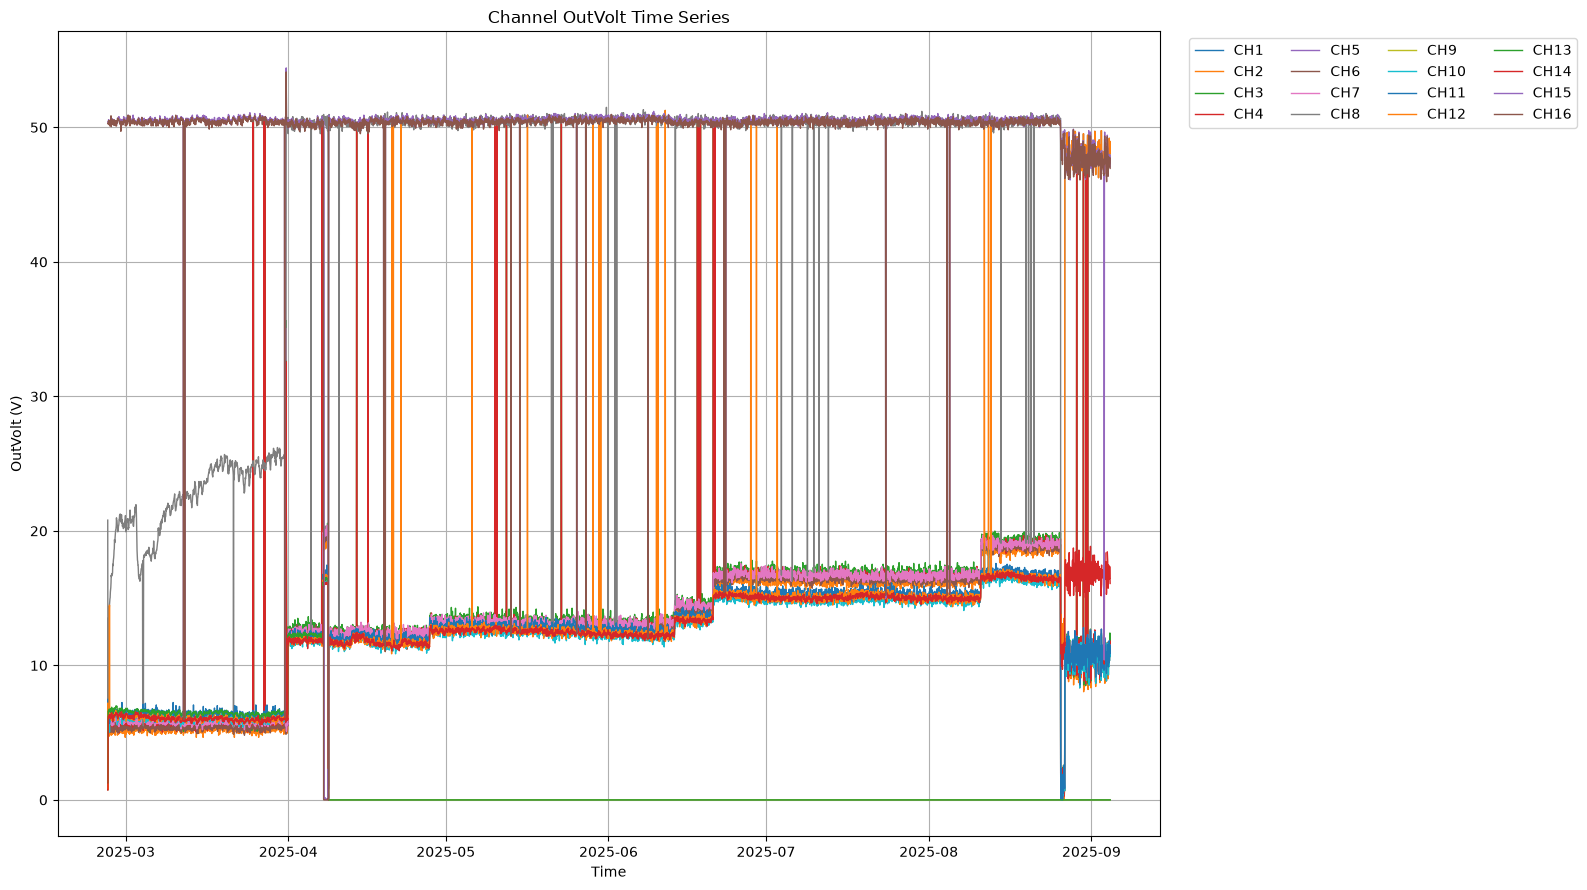

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 9))

for ch in range(1, 17):
    plt.plot(
        df["timestamp"],
        df[f"{ch}-OutVolt"],
        label=f"CH{ch}",
        linewidth=1
    )

plt.xlabel("Time")
plt.ylabel("OutVolt (V)")
plt.title("Channel OutVolt Time Series")
plt.legend(
    ncol=4,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(True)
plt.tight_layout()
plt.show()

표를 통해 알 수 있는 사실이 있습니다.
- 중간중간 세로로 떨어지거나 올라가는 것은 장비의 ON/OFF상태와 관련이 있어보입니다.
- 전압의 구간이 채널별로 동시에 계단식 형태로 반영되는 것으로 보아 설정값 변경등으로 함께 움직이는 것으로 보입니다.
- 그리고 일부 특정채널은 50V정도의 높은 전압구간에서 일정하게 운행이 되고 있고 다른 채널은 같은 전압 구간을 함께 움직이고 있습니다.

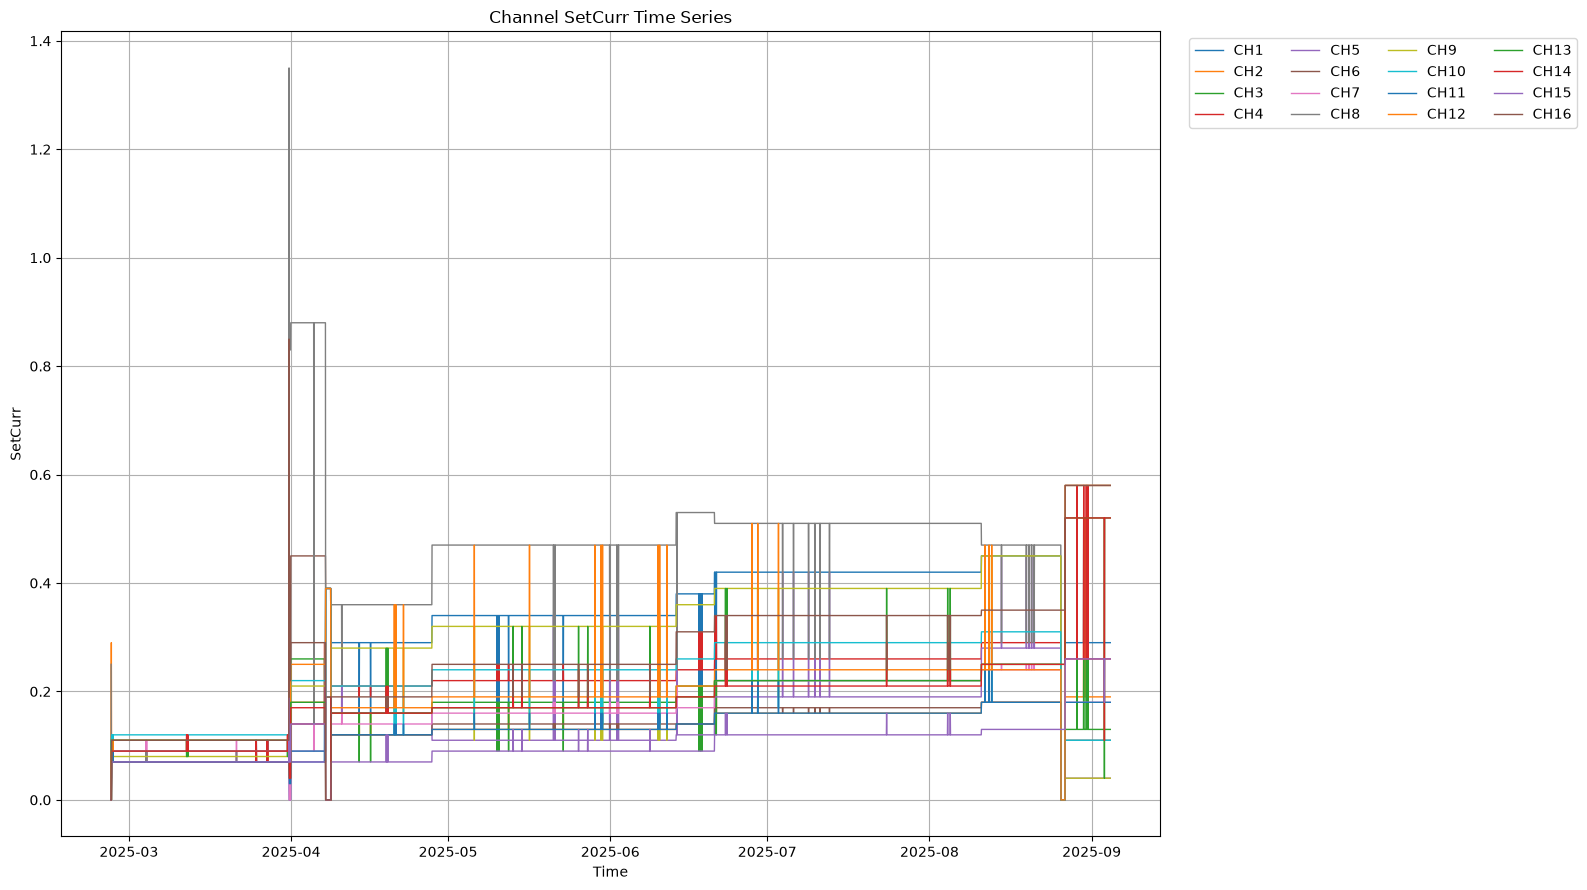

In [105]:
# ============================
# 16개 채널 SetCurr 시계열
# ============================

plt.figure(figsize=(16, 9))

for ch in range(1, 17):
    plt.plot(
        df["timestamp"],
        df[f"{ch}-SetCurr"],
        label=f"CH{ch}",
        linewidth=1
    )

plt.xlabel("Time")
plt.ylabel("SetCurr")
plt.title("Channel SetCurr Time Series")

plt.legend(
    ncol=4,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()
plt.show()

그래프를 통해 알 수 있는 사실
- 4월경에 여러 채널의 목표전류값 변화와 이전 전압그래프에서의 채널별 전압상승이 연관성이 있어보입니다.
- Setcurr의 변경과 OutVolt 운전점 변화가 관련되어 있을 가능성이 상당히 높습니다.

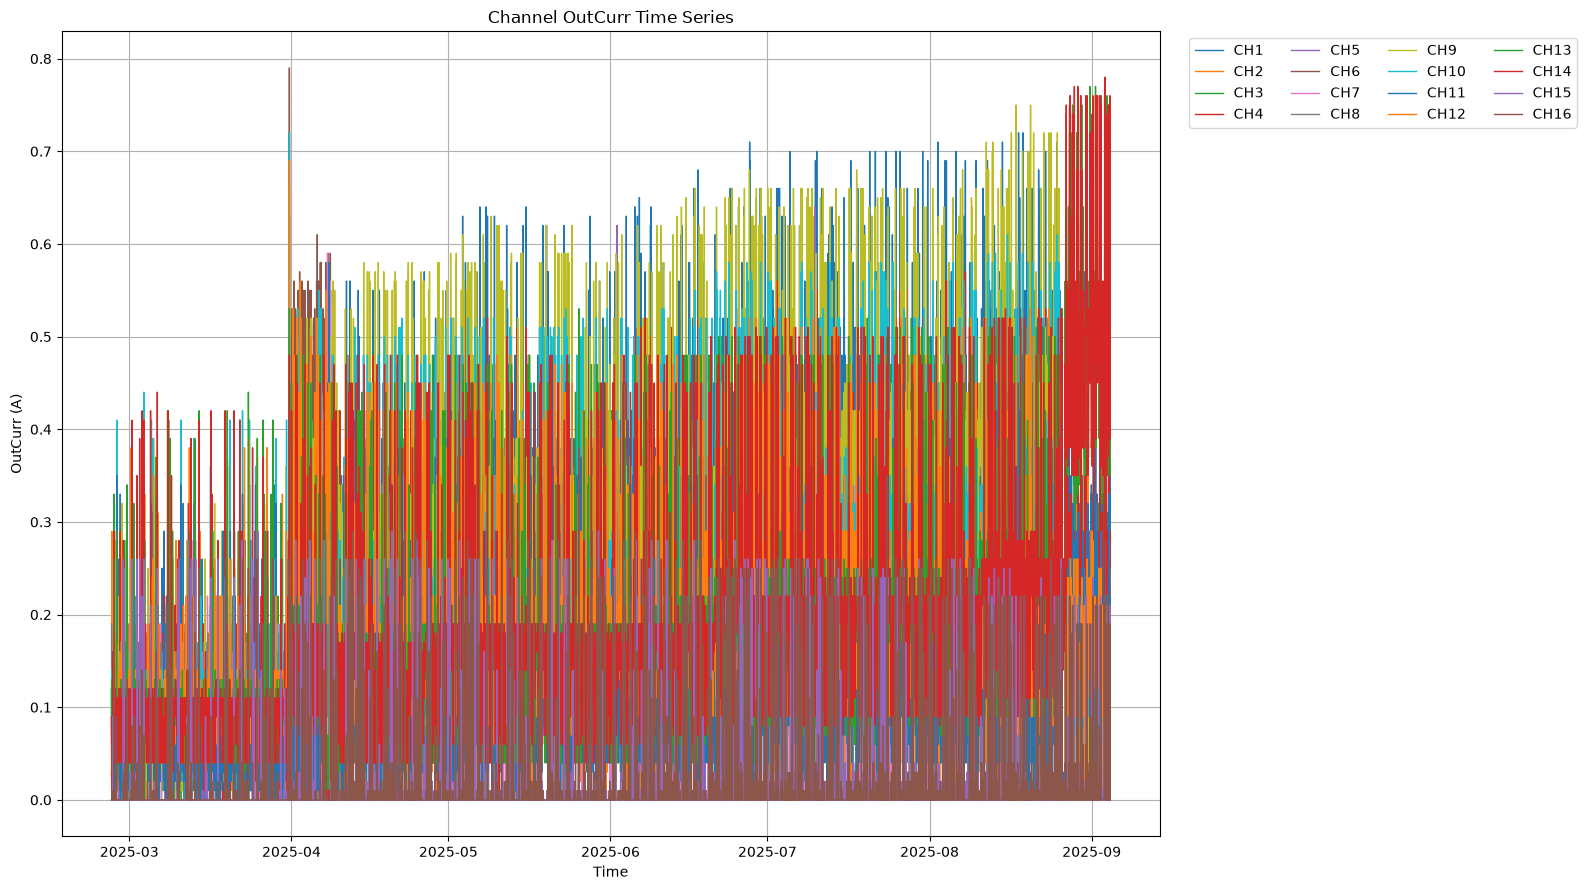

In [106]:
# ============================
# 16개 채널 OutCurr 시계열
# ============================

plt.figure(figsize=(16, 9))

for ch in range(1, 17):
    plt.plot(
        df["timestamp"],
        df[f"{ch}-OutCurr"],
        label=f"CH{ch}",
        linewidth=1
    )

plt.xlabel("Time")
plt.ylabel("OutCurr (A)")
plt.title("Channel OutCurr Time Series")

plt.legend(
    ncol=4,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()
plt.show()

동일한점
- 마찬가지로 4월을 기준으로 9월까지 까지 점점 그래프의 상단범위도 증가하는 것으로 보입니다.

차이점
- SetCurr는 깔끔한 계단형 설정값인데 OutCurr은 엄청 흔들리는 형태입니다.\
그래서 SetCurr = 실제 제어 설정값, OutCurr = 그 조건에서 실제로 측정된 출력 이라는 해석이 가능합니다.

In [107]:
# ============================
# 채널별 SetCurr - OutCurr 상관관계 확인
# ============================

correlation_result = []

for ch in range(1, 17):

    setcurr_col = f"{ch}-SetCurr"
    outcurr_col = f"{ch}-OutCurr"

    corr = df[setcurr_col].corr(df[outcurr_col])

    correlation_result.append({
        "Channel": ch,
        "SetCurr_OutCurr_Correlation": corr
    })

correlation_result = pd.DataFrame(correlation_result)

print(correlation_result.to_string(index=False))

 Channel  SetCurr_OutCurr_Correlation
       1                     0.879890
       2                     0.501853
       3                     0.671024
       4                     0.715366
       5                     0.710310
       6                     0.744064
       7                     0.618279
       8                     0.348976
       9                     0.842485
      10                     0.637147
      11                     0.458926
      12                     0.199795
      13                     0.698029
      14                     0.688117
      15                     0.091454
      16                     0.092133


설정 전류와 출력 전류와의 상관관계 수치입니다.
이를 통해 알 수 있는 것은
- 강한관계:1,4,5,6,9는 설정전류가 높아질수록 실제 출력전류도 높아지는 경향이 뚜렷합니다.
- 중간관계:2,3,7,10,13,14 등은 관계는 있지만 다른 요인의 영향도 상당히 있어보입니다.
- 약한관계:8,12 특히 15,16은 약 0.09로 이 채널들은 SetCurr만 가지고 OutCurr를 설명하기 어렵습니다.

[TB1-Volt 기본 통계]
count    4584.000000
mean    -2248.594895
std       488.352618
min     -3356.000000
25%     -2519.000000
50%     -2446.000000
75%     -2413.000000
max      -966.000000
Name: TB1-Volt, dtype: float64


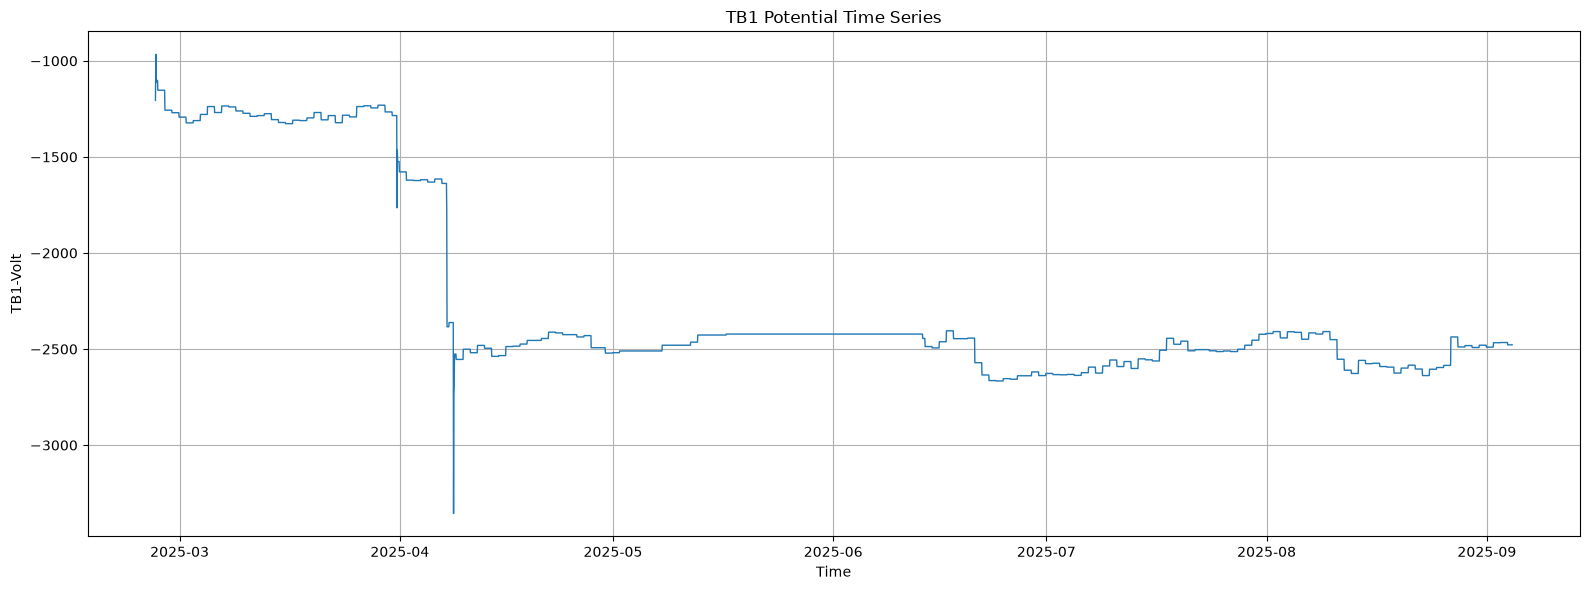

In [108]:
# ============================
# TB1-Volt 기본 통계
# ============================

print("[TB1-Volt 기본 통계]")
print(df["TB1-Volt"].describe())


# ============================
# TB1-Volt 시계열 그래프
# ============================

plt.figure(figsize=(16, 6))

plt.plot(
    df["timestamp"],
    df["TB1-Volt"],
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("TB1-Volt")
plt.title("TB1 Potential Time Series")
plt.grid(True)
plt.tight_layout()
plt.show()

마찬가지로 TB1도 같은 기간동안 더 음(-)의 방향으로 이동한 것을 통해 설정 전류에따른 출력전류 및 출력전압과
연관성이 높은것으로 확인됩니다.

즉 데이터만 놓고 보면 이런 가설이 자연스러워 집니다.
$$ SetCurr↑ $$
$$ \Downarrow $$ $$ OutCurr / OutVolt\text{ 운전조건 변화} $$ $$ \Downarrow $$
$$ TB1 Potential→더 음(-)의 방향 $$

In [109]:
# ============================
# TB1 전위 변화량 계산
# ============================

df["TB1-Volt_next"] = df["TB1-Volt"].shift(-1)

df["Delta_TB1_Volt"] = (
    df["TB1-Volt_next"] - df["TB1-Volt"]
)

print("[TB1 전위 변화량 통계]")
print(df["Delta_TB1_Volt"].describe())

# 다음 행까지의 시간 간격
df["next_time_diff"] = df["timestamp"].shift(-1) - df["timestamp"]

# 정상적인 약 1시간 간격인지 확인
df["valid_transition"] = (
    (df["next_time_diff"] >= pd.Timedelta(minutes=59)) &
    (df["next_time_diff"] <= pd.Timedelta(minutes=61))
)

print("\n[정상 1시간 transition]")
print(df["valid_transition"].value_counts())

[TB1 전위 변화량 통계]
count    4583.000000
mean       -0.277547
std        22.551938
min      -994.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       617.000000
Name: Delta_TB1_Volt, dtype: float64

[정상 1시간 transition]
valid_transition
True     4583
False       1
Name: count, dtype: int64


- 시간 간격 검사에서 False가 1개 나온이유는 마지막 행의 그다음 데이터가 없어서 그런 것입니다.(정상)
- 여기서 핵심은 25%,50%,75% 구간에서 전부 0이라는 점 입니다 적어도 많은 시간동안 그대로 유지되는 구간이 많다는 뜻입니다.

[고려사항]
- 0인 구간이 너무 많으면 모델이 꼼수를 익힐 가능성이 높습니다. 그래서 ΔTB = 0이 정확히 몇 개인지, 그리고 변화량이 어느 정도로 분포하는지 확인이 필요합니다.

In [110]:
# ============================
# TB1 전위 변화량 상세 확인
# ============================

valid_delta = df.loc[
    df["valid_transition"],
    "Delta_TB1_Volt"
]

print("[전체 transition]")
print(len(valid_delta))

print("\n[변화 없음 : Delta = 0]")
print((valid_delta == 0).sum())

print("\n[변화 있음 : Delta != 0]")
print((valid_delta != 0).sum())

print("\n[변화 없음 비율]")
print(
    round((valid_delta == 0).mean() * 100, 2),
    "%"
)

print("\n[절대 변화량 분위수]")
print(valid_delta.abs().describe(
    percentiles=[0.90, 0.95, 0.99]
))

# ============================
# TB1 전위 변화량이 큰 구간 확인
# ============================

large_changes = df.loc[
    df["valid_transition"],
    [
        "timestamp",
        "TB1-Volt",
        "TB1-Volt_next",
        "Delta_TB1_Volt"
    ]
].copy()

large_changes["Abs_Delta"] = (
    large_changes["Delta_TB1_Volt"].abs()
)

large_changes = large_changes.sort_values(
    "Abs_Delta",
    ascending=False
)

print("\n[TB1 전위 변화량 TOP 20]")
print(
    large_changes.head(20).to_string(index=False)
)

[전체 transition]
4583

[변화 없음 : Delta = 0]
4421

[변화 있음 : Delta != 0]
162

[변화 없음 비율]
96.47 %

[절대 변화량 분위수]
count    4583.000000
mean        1.627318
std        22.494849
min         0.000000
90%         0.000000
95%         0.000000
99%        34.180000
max       994.000000
Name: Delta_TB1_Volt, dtype: float64

[TB1 전위 변화량 TOP 20]
          timestamp  TB1-Volt  TB1-Volt_next  Delta_TB1_Volt  Abs_Delta
2025-04-08 12:30:01     -2362        -3356.0          -994.0      994.0
2025-04-08 13:30:01     -3356        -2739.0           617.0      617.0
2025-04-07 14:30:01     -1778        -2384.0          -606.0      606.0
2025-03-31 13:30:01     -1285        -1765.0          -480.0      480.0
2025-03-31 14:30:01     -1765        -1465.0           300.0      300.0
2025-02-25 14:30:01     -1206        -1017.0           189.0      189.0
2025-08-26 21:30:01     -2585        -2437.0           148.0      148.0
2025-02-25 16:30:01      -966        -1112.0          -146.0      146.0
2025-04-08 15:30:01

#### 결과를 통해 알 수 있는 것
- TB1은 4583개의 정상 1시간 전이 중 4421개, 즉 96.47%에서 값이 변하지 않습니다.
- 3월과 4월에 큰 변화가 집중되어 있습니다.

#### 진행한 이유
- 모델의 학습에 올바르게 영향을 줄 수 있는 데이터인가? 확인이 필요합니다. 변화가 없는 데이터일수록 학습성능이 떨어집니다.
- 활용하기 좋은 구간이 어떤 구간인지? 그리고 설정정류 변화구간과 TB전위 변화구간이 일치하는지 확인을 위해 진행하였습니다.

#### 다음으로 진행 할 것
- ΔSetCurr를 만들어야 합니다.
$$ \boxed{\text{SetCurr 변경} \rightarrow \text{TB 전위 변화}} $$


In [111]:
# ============================
# 16개 채널 SetCurr 변화량 계산
# ============================

for ch in range(1, 17):

    current_col = f"{ch}-SetCurr"
    delta_col = f"Delta_{ch}_SetCurr"

    df[delta_col] = (
        df[current_col].shift(-1)
        - df[current_col]
    )

#### 다음으로 진행 할 것
- 16채널 중 하나라도 설정이 변경됐는가?를 만들어야합니다.

In [112]:
# Delta SetCurr 컬럼 이름
delta_setcurr_cols = [
    f"Delta_{ch}_SetCurr"
    for ch in range(1, 17)
]

# 16개 채널 중 하나라도 SetCurr가 변경됐는지
df["SetCurr_changed"] = (
    df[delta_setcurr_cols]
    .abs()
    .gt(1e-9)
    .any(axis=1)
)

# 정상적인 1시간 transition만 분석
valid_df = df[df["valid_transition"]].copy()

print("[SetCurr 변경 여부]")
print(valid_df["SetCurr_changed"].value_counts())

print("\n[SetCurr 변경 비율]")
print(
    round(
        valid_df["SetCurr_changed"].mean() * 100,
        2
    ),
    "%"
)

[SetCurr 변경 여부]
SetCurr_changed
False    4415
True      168
Name: count, dtype: int64

[SetCurr 변경 비율]
3.67 %


#### 결과를 통해 알 수 있는 것
- TB1의 변경된 transition의 162와 설정전류가 변경된 transition의 168의 갯수가 상당히 비슷하다는 것 입니다.

#### 다음으로 진행 할 것
- 이제 변경시점이 실제로 일치하는 지?를 확인해야 합니다.

In [113]:
# ============================
# TB1 전위 변경 여부 생성
# ============================

valid_df["TB1_changed"] = (
    valid_df["Delta_TB1_Volt"].abs() > 1e-9
)

# ============================
# SetCurr 변경과 TB1 변경 비교
# ============================

comparison = pd.crosstab(
    valid_df["SetCurr_changed"],
    valid_df["TB1_changed"],
    margins=True
)

print("[SetCurr 변경 vs TB1 전위 변경]")
print(comparison)

# ============================
# 조건별 TB1 변경 확률
# ============================

tb_change_when_setcurr_changed = valid_df.loc[
    valid_df["SetCurr_changed"],
    "TB1_changed"
].mean() * 100

tb_change_when_setcurr_not_changed = valid_df.loc[
    ~valid_df["SetCurr_changed"],
    "TB1_changed"
].mean() * 100

print(
    "[SetCurr 변경 시 TB1 변경 비율]",
    round(tb_change_when_setcurr_changed, 2),
    "%"
)

print(
    "[SetCurr 미변경 시 TB1 변경 비율]",
    round(tb_change_when_setcurr_not_changed, 2),
    "%"
)

[SetCurr 변경 vs TB1 전위 변경]
TB1_changed      False  True   All
SetCurr_changed                   
False             4274   141  4415
True               147    21   168
All               4421   162  4583
[SetCurr 변경 시 TB1 변경 비율] 12.5 %
[SetCurr 미변경 시 TB1 변경 비율] 3.19 %


#### 결과에서 알 수 있는 것
- SetCurr 변경 시 TB도 변경될 확률이 약3.9배 높습니다.
#### 중요한 문제
- SetCurr가 벼경된 168개 중 같은 1시간 trasition에서 TB까지 바뀐 건 21개뿐이라는 점 입니다.
#### 가능성
- 값이 변경되더라도 변경이 반영되기까지의 시간지연 문제가 영향이 있을 수 있습니다.
#### 다음으로 진행할 것
- SetCurr 변경 후 0~6시간 TB 반응 확인


In [114]:
# ============================
# SetCurr 변경 후 TB1 반응 지연(lag) 분석
# ============================

lag_results = []

for lag in range(0, 7):

    # SetCurr 변경 시점을 기준으로
    # lag시간 뒤 TB1 변경 여부를 가져옴
    future_tb_changed = valid_df["TB1_changed"].shift(-lag)

    # 마지막 부분의 NaN 제외
    mask = (
        valid_df["SetCurr_changed"] &
        future_tb_changed.notna()
    )

    total_setcurr_changes = mask.sum()

    tb_changed_count = (
        future_tb_changed[mask].sum()
    )

    tb_changed_ratio = (
        tb_changed_count / total_setcurr_changes * 100
        if total_setcurr_changes > 0
        else 0
    )

    lag_results.append({
        "Lag_hour": lag,
        "SetCurr_change_count": total_setcurr_changes,
        "TB_changed_count": int(tb_changed_count),
        "TB_changed_ratio(%)": round(tb_changed_ratio, 2)
    })


lag_result_df = pd.DataFrame(lag_results)

print("[SetCurr 변경 후 TB1 변화 Lag 분석]")
print(lag_result_df.to_string(index=False))

[SetCurr 변경 후 TB1 변화 Lag 분석]
 Lag_hour  SetCurr_change_count  TB_changed_count  TB_changed_ratio(%)
        0                   168                21                12.50
        1                   168                11                 6.55
        2                   168                 6                 3.57
        3                   168                 4                 2.38
        4                   168                 4                 2.38
        5                   168                 5                 2.98
        6                   168                 6                 3.57


#### 결과에서 알 수 있는 것
- TB의 변화는 SetCurr의 변화와 거의 같은 구간에서 많이 일어나고 시간 지연의 가능성은 비교적 적다.
- TB만의 전위 변화보다 SetCurr의 변화가 TB변화와 연관성이 있다는 것을 알 수 있다. (약 3.9배 높기 떄문)
#### 다음으로 해야하는 것
- 얼마나 제어 했더니 전위가 어느 방향으로 얼마나 변했는가?


In [115]:
# ============================
# SetCurr가 변경된 transition만 추출
# ============================

setcurr_change_df = valid_df[
    valid_df["SetCurr_changed"]
].copy()

# 확인할 컬럼
cols = (
    ["timestamp"] +
    [f"Delta_{ch}_SetCurr" for ch in range(1, 17)] +
    ["Delta_TB1_Volt"]
)

print("[SetCurr 변경 transition]")
print(
    setcurr_change_df[cols]
    .head(30)
    .to_string(index=False)
)

[SetCurr 변경 transition]
          timestamp  Delta_1_SetCurr  Delta_2_SetCurr  Delta_3_SetCurr  Delta_4_SetCurr  Delta_5_SetCurr  Delta_6_SetCurr  Delta_7_SetCurr  Delta_8_SetCurr  Delta_9_SetCurr  Delta_10_SetCurr  Delta_11_SetCurr  Delta_12_SetCurr  Delta_13_SetCurr  Delta_14_SetCurr  Delta_15_SetCurr  Delta_16_SetCurr  Delta_TB1_Volt
2025-02-25 14:30:01            -0.03             0.20            -0.11            -0.09            -0.06            -0.01            -0.07            -0.21            -0.07             -0.11             -0.09             -0.09              0.00              0.00              0.00              0.00           189.0
2025-02-25 15:30:01             0.03            -0.22             0.07             0.07             0.09             0.07             0.11             0.05             0.08              0.12              0.07              0.11              0.11              0.09              0.07              0.11            51.0
2025-02-25 21:30:01            

#### 다음으로 해야하는 것
- 한 번에 몇 개 채널이 바뀌는지?

In [116]:
# ============================
# 한 transition에서 변경된 채널 수
# ============================

setcurr_change_df["Changed_Channel_Count"] = (
    setcurr_change_df[
        [f"Delta_{ch}_SetCurr" for ch in range(1, 17)]
    ]
    .abs()
    .gt(1e-9)
    .sum(axis=1)
)

print("[동시에 변경된 SetCurr 채널 수]")
print(
    setcurr_change_df["Changed_Channel_Count"]
    .value_counts()
    .sort_index()
)

print("\n[통계]")
print(
    setcurr_change_df["Changed_Channel_Count"]
    .describe()
)

[동시에 변경된 SetCurr 채널 수]
Changed_Channel_Count
2       8
3      42
4     102
9       1
10      1
12      2
14      2
15      1
16      9
Name: count, dtype: int64

[통계]
count    168.000000
mean       4.642857
std        3.292681
min        2.000000
25%        3.000000
50%        4.000000
75%        4.000000
max       16.000000
Name: Changed_Channel_Count, dtype: float64


#### 결과에서 알 수 있는 것
- 특정 채널들이 묶여서 조정되는 구조가 존재할 가능성이 있습니다.
- 1개 채널만 변경된 경우가 하나도 없습니다.
- 4개 채널이 동시에 변경된 경우가 102번으로 압도적으로 많습니다.

#### 다음으로 알아내야 하는 것
- SetCurr를 어느 방향으로 얼마나 변화시키면 TB가 어느 방향으로 얼마나 움직이는가?
1. 전체적인 증가/감소 방향
2. 얼마나 큰 조작이 있었는지

In [117]:
# ============================
# SetCurr 전체 변화 방향 / 변화 크기
# ============================

delta_cols = [
    f"Delta_{ch}_SetCurr"
    for ch in range(1, 17)
]

# 전체적인 증가/감소 방향
valid_df["Total_Delta_SetCurr"] = (
    valid_df[delta_cols].sum(axis=1)
)

# 실제 조작 크기
valid_df["Total_Abs_Delta_SetCurr"] = (
    valid_df[delta_cols].abs().sum(axis=1)
)

# SetCurr가 실제로 변경된 168개만 추출
change_events = valid_df[
    valid_df["SetCurr_changed"]
].copy()

print("[SetCurr 변경 이벤트 통계]")

print(
    change_events[
        [
            "Total_Delta_SetCurr",
            "Total_Abs_Delta_SetCurr",
            "Delta_TB1_Volt"
        ]
    ].describe()
)

# ============================
# SetCurr 변화 방향과 TB1 변화 방향 비교
# ============================

# SetCurr 증가 → TB가 더 음(-)으로 이동
increase_correct = (
    (change_events["Total_Delta_SetCurr"] > 0) &
    (change_events["Delta_TB1_Volt"] < 0)
)

# SetCurr 감소 → TB가 더 양(+)으로 이동
decrease_correct = (
    (change_events["Total_Delta_SetCurr"] < 0) &
    (change_events["Delta_TB1_Volt"] > 0)
)

direction_match = increase_correct | decrease_correct

print("[전체 SetCurr 증가 이벤트]")
print(
    (change_events["Total_Delta_SetCurr"] > 0).sum()
)

print("\n[전체 SetCurr 감소 이벤트]")
print(
    (change_events["Total_Delta_SetCurr"] < 0).sum()
)

print("\n[예상 방향으로 TB가 움직인 이벤트]")
print(direction_match.sum())

print("\n[SetCurr 변경 이벤트 전체 기준 방향 일치율]")
print(
    round(direction_match.mean() * 100, 2),
    "%"
)

[SetCurr 변경 이벤트 통계]
       Total_Delta_SetCurr  Total_Abs_Delta_SetCurr  Delta_TB1_Volt
count           168.000000               168.000000      168.000000
mean              0.020595                 0.639762        1.982143
std               1.067897                 0.983401       71.226507
min              -7.740000                 0.060000     -480.000000
25%              -0.030000                 0.327500        0.000000
50%               0.000000                 0.430000        0.000000
75%               0.085000                 0.620000        0.000000
max               8.400000                 8.400000      617.000000
[전체 SetCurr 증가 이벤트]
77

[전체 SetCurr 감소 이벤트]
73

[예상 방향으로 TB가 움직인 이벤트]
14

[SetCurr 변경 이벤트 전체 기준 방향 일치율]
8.33 %


#### 결과를 통해 알 수 있는 것
- 전체 168회 중 14회(14/168 = 8.33%)가 예상한 방향과 일치합니다.
- SetCurr변경 시 TB가 변화한 사례 21회와 비교해보면 실제 변화율은 14/21 = 66.7%가 됩니다.

#### 고려할 사항
- Total_Delta_Setcurr를 아직 완전히 신뢰할 수 없습니다. (단순 합산이기 때문에)
- Total_Delta_Setcurr는 0인데 Total_Abs_Delta_SetCurr를 보면 0.43과 같이 서로 상쇄되어 버리는 경우가 있습니다.
- 이후로는 TB가 실제로 변한 21개만 직접 들여다 보는 것이 좋습니다.

In [119]:
# ============================================
# SetCurr도 변경되고 TB1도 실제로 변경된 이벤트
# ============================================

response_events = change_events[
    change_events["Delta_TB1_Volt"].abs() > 1e-9
].copy()


# ============================================
# 변경된 채널 수 다시 계산
# ============================================

delta_cols = [
    f"Delta_{ch}_SetCurr"
    for ch in range(1, 17)
]

response_events["Changed_Channel_Count"] = (
    response_events[delta_cols]
    .abs()
    .gt(1e-9)
    .sum(axis=1)
)


# ============================================
# 방향 판정
# ============================================

def check_direction(row):

    total_delta = row["Total_Delta_SetCurr"]
    tb_delta = row["Delta_TB1_Volt"]

    if total_delta > 0 and tb_delta < 0:
        return "예상방향"

    elif total_delta < 0 and tb_delta > 0:
        return "예상방향"

    elif abs(total_delta) < 1e-9:
        return "합계0"

    else:
        return "반대방향"


response_events["Direction_Result"] = response_events.apply(
    check_direction,
    axis=1
)


# ============================================
# 결과 출력
# ============================================

print("[SetCurr 변경 + TB1 실제 변경 이벤트 수]")
print(len(response_events))

print("\n[방향 판정]")
print(
    response_events["Direction_Result"].value_counts()
)

print("\n[이벤트 상세]")
print(
    response_events[
        [
            "timestamp",
            "Changed_Channel_Count",
            "Total_Delta_SetCurr",
            "Total_Abs_Delta_SetCurr",
            "Delta_TB1_Volt",
            "Direction_Result"
        ]
    ].to_string(index=False)
)

[SetCurr 변경 + TB1 실제 변경 이벤트 수]
21

[방향 판정]
Direction_Result
예상방향    14
반대방향     7
Name: count, dtype: int64

[이벤트 상세]
          timestamp  Changed_Channel_Count  Total_Delta_SetCurr  Total_Abs_Delta_SetCurr  Delta_TB1_Volt Direction_Result
2025-02-25 14:30:01                     12                -0.74                     1.14           189.0             예상방향
2025-02-25 15:30:01                     16                 1.03                     1.47            51.0             반대방향
2025-02-25 21:30:01                      4                -0.02                     0.12           -51.0             반대방향
2025-03-31 13:30:01                     16                 8.40                     8.40          -480.0             예상방향
2025-03-31 14:30:01                     16                -7.74                     7.74           300.0             예상방향
2025-03-31 15:30:01                     10                 0.02                     0.34           -59.0             예상방향
2025-03-31 21:30:01         

In [120]:
# ============================================
# TB1이 실제로 변경된 전체 이벤트의 시간대 분석
# ============================================

tb_change_events = valid_df[
    valid_df["Delta_TB1_Volt"].abs() > 1e-9
].copy()

# Delta_TB1_Volt는 t → t+1 변화이므로
# 실제 새로운 TB 값이 기록된 시각은 다음 timestamp
tb_change_events["TB_Update_Time"] = (
    tb_change_events["timestamp"].shift(-1)
)

# 단, 위 shift는 필터링 후 하면 행이 끊기므로
# 정확한 다음 시각은 1시간을 더하는 방식 사용
tb_change_events["TB_Update_Time"] = (
    tb_change_events["timestamp"]
    + pd.Timedelta(hours=1)
)

tb_change_events["Update_Hour"] = (
    tb_change_events["TB_Update_Time"].dt.hour
)

print("[TB1 변경 이벤트 전체]")
print(len(tb_change_events))

print("\n[TB1 변경 시각별 횟수]")
print(
    tb_change_events["Update_Hour"]
    .value_counts()
    .sort_index()
)

print("\n[TB1 변경 시각별 비율(%)]")
print(
    (
        tb_change_events["Update_Hour"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

[TB1 변경 이벤트 전체]
162

[TB1 변경 시각별 횟수]
Update_Hour
13      1
14      4
15      4
16      3
17      2
18      1
22    147
Name: count, dtype: int64

[TB1 변경 시각별 비율(%)]
Update_Hour
13     0.62
14     2.47
15     2.47
16     1.85
17     1.23
18     0.62
22    90.74
Name: proportion, dtype: float64


In [121]:
# ============================================
# TB1-Volt의 실제 시간별 기록 확인
# 예: 6월 중 며칠을 그대로 출력
# ============================================

sample = df[
    (df["timestamp"] >= "2025-06-15 00:00:00") &
    (df["timestamp"] <= "2025-06-19 23:59:59")
][
    [
        "timestamp",
        "TB1-Volt",
        "TB1-Min",
        "TB1-Max"
    ]
]

print(sample.to_string(index=False))

          timestamp  TB1-Volt  TB1-Min  TB1-Max
2025-06-15 00:30:01     -2494    -2400    -2700
2025-06-15 01:30:01     -2494    -2400    -2700
2025-06-15 02:30:01     -2494    -2400    -2700
2025-06-15 03:30:01     -2494    -2400    -2700
2025-06-15 04:30:01     -2494    -2400    -2700
2025-06-15 05:30:01     -2494    -2400    -2700
2025-06-15 06:30:01     -2494    -2400    -2700
2025-06-15 07:30:01     -2494    -2400    -2700
2025-06-15 08:30:01     -2494    -2400    -2700
2025-06-15 09:30:01     -2494    -2400    -2700
2025-06-15 10:30:01     -2494    -2400    -2700
2025-06-15 11:30:01     -2494    -2400    -2700
2025-06-15 12:30:01     -2494    -2400    -2700
2025-06-15 13:30:01     -2494    -2400    -2700
2025-06-15 14:30:01     -2494    -2400    -2700
2025-06-15 15:30:01     -2494    -2400    -2700
2025-06-15 16:30:01     -2494    -2400    -2700
2025-06-15 17:30:01     -2494    -2400    -2700
2025-06-15 18:30:01     -2494    -2400    -2700
2025-06-15 19:30:01     -2494    -2400  